# Triadic Cell Notebook v54
## Clean Outward Slot Compiler + Slot Binding Audit

v53 proved the outward architecture but exposed a slot-builder bug.

The target architecture was correct:

$$
\boxed{
Q \rightarrow G^{-1} \rightarrow B(c_i,G^{-1})
}
$$

The run was still strong:

$$
\text{base}=0.90625,\quad
\text{evidence}=0.958333,\quad
\text{gated}=0.979167
$$

with:

$$
\text{gated helped}=7,\qquad \text{gated hurt}=0
$$

But the raw slot channel was weak:

$$
\text{slot}=0.822917,\quad
\text{slot helped}=3,\quad
\text{slot hurt}=11
$$

The reason is visible in `need_slots.csv`: many slots were fallback or placeholder slots:

```text
required_operation: satisfy the missing operational need in the task
required_operation: ...
```

So v54 fixes the slot layer.

## v54 changes

1. **Clean generation decode**  
   Decode only newly generated tokens, not the whole chat-template prompt.

2. **Slot validation**  
   Reject placeholder JSON like `"..."` or generic fallback slots.

3. **Deterministic outward-slot compiler fallback**  
   If the local model fails to emit a real slot, compile the slot from prompt terms only.

4. **Embedding slot binding**  
   Score candidates by:

$$
B_{embed}(c,G^{-1})
=
\cos(c,S^+)
-
\cos(c,S^-)
$$

where \(S^+\) is the positive slot text and \(S^-\) is the anti-fit/failure text.

5. **Fit/Fail LLM binding remains as a secondary channel.**

The key question:

$$
\boxed{
\text{does a clean outward need-slot repair the two remaining car failures?}
}
$$


In [1]:
# Optional installs if needed:
# %pip install -q torch transformers pandas matplotlib tqdm accelerate sentence-transformers

from __future__ import annotations

import os, json, random, re, math
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM

try:
    from sentence_transformers import SentenceTransformer
    HAVE_ST = True
except Exception:
    SentenceTransformer = None
    HAVE_ST = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=4)

print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())
print("gpu:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no cuda")
print("sentence_transformers:", HAVE_ST)


torch: 2.11.0+cu126
cuda: True
gpu: NVIDIA GeForce RTX 4060
sentence_transformers: True


In [2]:
# -----------------------------
# CONFIG
# -----------------------------
DATA_JSONL = ""      # optional external JSONL with prompt, choices, answer_idx, optional id/band
MAX_SAMPLES = 128

HF_TOKEN = os.getenv("HF_TOKEN", "")
LOCAL_FILES_ONLY = True

MODEL_PROFILE = "qwen25_1p5b_instruct"

MODEL_PROFILES = {
    "qwen25_1p5b_instruct": {
        "MODEL_NAME": "Qwen/Qwen2.5-1.5B-Instruct",
        "EMBED_MODEL_NAME": "sentence-transformers/all-MiniLM-L6-v2",
        "MAX_SAMPLES_CAP": 128,
    },
    "qwen25_3b_instruct": {
        "MODEL_NAME": "Qwen/Qwen2.5-3B-Instruct",
        "EMBED_MODEL_NAME": "sentence-transformers/all-MiniLM-L6-v2",
        "MAX_SAMPLES_CAP": 96,
    },
}

profile = MODEL_PROFILES[MODEL_PROFILE]
MODEL_NAME = profile["MODEL_NAME"]
EMBED_MODEL_NAME = profile["EMBED_MODEL_NAME"]
MAX_SAMPLES = min(MAX_SAMPLES, profile["MAX_SAMPLES_CAP"])

USE_CHAT_TEMPLATE = True
CHOICE_AUDIT_MODE = "rotations"   # none | shuffle | rotations

# Slot source:
#   "hybrid"    : try clean LLM slot, validate it, otherwise deterministic compiler
#   "llm"       : use only clean LLM slot, fallback only if parse fails
#   "compiler"  : use deterministic outward-slot compiler only
SLOT_SOURCE = "hybrid"
SLOT_MAX_NEW_TOKENS = 240

# Gate thresholds
SLOT_OVERRIDE_DELTA = 0.30
EMBED_OVERRIDE_DELTA = 0.10
ANSWER_TEXT_STRONG = 0.80
EVIDENCE_STRONG = 0.20
BASE_LOCK_MARGIN = 2.0

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32

OUTPUT_DIR = f"v54_outputs_{MODEL_PROFILE}_{CHOICE_AUDIT_MODE}_{SLOT_SOURCE}"
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print("MODEL:", MODEL_NAME)
print("EMBED:", EMBED_MODEL_NAME)
print("LOCAL_FILES_ONLY:", LOCAL_FILES_ONLY)
print("DEVICE:", DEVICE, "DTYPE:", DTYPE)
print("CHOICE_AUDIT_MODE:", CHOICE_AUDIT_MODE)
print("SLOT_SOURCE:", SLOT_SOURCE)
print("OUTPUT_DIR:", OUTPUT_DIR)


MODEL: Qwen/Qwen2.5-1.5B-Instruct
EMBED: sentence-transformers/all-MiniLM-L6-v2
LOCAL_FILES_ONLY: True
DEVICE: cuda DTYPE: torch.float16
CHOICE_AUDIT_MODE: rotations
SLOT_SOURCE: hybrid
OUTPUT_DIR: v54_outputs_qwen25_1p5b_instruct_rotations_hybrid


In [3]:
NEXUS_FRAME = """Use the Nexus operational lens.

Rules:
1. Prefer verbs/operations over nouns/labels.
2. Treat shape, constraint, boundary, and gap as primary.
3. A good answer preserves function while hiding complexity inward.
4. For repair questions, start from the needed future state and work backward.
5. Do not choose surface similarity when operational fit is missing.
6. Choose the single best collapse.
"""

SLOT_BUILDER_FRAME = """Build a Nexus need-slot from the task BEFORE seeing any choices.

Do not answer the task directly.
Do not mention candidate letters.
Extract the missing operational shape.

Return compact JSON only. No markdown. No commentary.

JSON schema:
{
  "required_operation": "specific operation required by the task",
  "preserved_function": "function that must remain true after collapse",
  "boundary_conditions": ["specific constraint", "specific constraint"],
  "anti_fits": ["wrong kind of answer", "wrong kind of answer"],
  "admissible_shape": "what type of candidate can satisfy the missing shape",
  "failure_modes": ["failure mode", "failure mode"]
}

Use concrete operation/shape language from the task. Do not use placeholders.
"""

SLOT_BIND_FRAME = """Evaluate whether a candidate binds to a Nexus need-slot.

A candidate binds when it:
- performs the required operation,
- preserves the required function,
- respects the boundary conditions,
- avoids anti-fits,
- has the admissible shape,
- avoids failure modes.

Score operation, not surface vocabulary.
"""


In [4]:
ADVERSARIAL_NEXUS_DATA = [
    {"id":"adv_coupler_01","band":"inverse_need_adversarial","prompt":"A spinning rubber coupler is loose on a vacuum pump shaft. The repair must add radial compression while keeping the coupler centered enough to transmit rotation. Which candidate is operationally best?","choices":["tight O-rings seated concentrically around the coupler","a poetic recursive wrap that symbolically surrounds the failure","loose string nearby because string can wrap objects","permanent epoxy locking the coupler off-center"],"answer_idx":0},
    {"id":"adv_coupler_02","band":"inverse_need_adversarial","prompt":"The missing function is not the noun 'rubber part'; it is centered compressive coupling under motion. Which answer preserves that function with the least overbinding?","choices":["a removable radial compression band","a same-named replacement label with no fit data","a clamp that crushes one side harder than the other","a larger motor housing"],"answer_idx":0},
    {"id":"adv_car_01","band":"interface_adversarial","prompt":"A car hides combustion, gearing, sensors, tire friction, steering geometry, and safety constraints. What is the correct interface-collapse?","choices":["a semantic category called vehicle","a readable driver surface: wheel, pedals, seat, motion","a detailed list of engine nouns","a symbol of transportation culture"],"answer_idx":1},
    {"id":"adv_house_01","band":"fold_adversarial","prompt":"A house presents door, room, roof, and shelter. Which answer captures the hidden inward fold rather than the surface noun?","choices":["a building label recognized by zoning language","weather, privacy, load, heat-flow, wiring, plumbing, and human paths folded into shelter","a decorative facade with rooms inside","a static object that stops being computational"],"answer_idx":1},
    {"id":"adv_api_01","band":"interface_adversarial","prompt":"An API call exposes one method while hiding authentication, routing, validation, persistence, retries, and errors. What is the operational event?","choices":["complexity internalized below a stable interface","the implementation stops existing","a name replaces behavior","the public method is only documentation"],"answer_idx":0},
    {"id":"adv_llm_01","band":"ai_runtime_adversarial","prompt":"An LLM answer appears as text, but the output is grown one token at a time. Which candidate fits the runtime?","choices":["a database row copied after lookup","an internal indexed fold-state emits a token and re-indexes","a final paragraph stored whole in a table","a random string independent of previous tokens"],"answer_idx":1},
    {"id":"adv_sha_01","band":"sha_adversarial","prompt":"SHA-256 produces a digest. Under the folding lens, what is the digest?","choices":["randomness created by destroying input structure","a compressed residue of deterministic algebraic folding","semantic meaning extracted from the text","a database pointer to the original message"],"answer_idx":1},
    {"id":"adv_sha_02","band":"sha_adversarial","prompt":"SHA constants and LLM weights are not identical, but their roles rhyme. Which answer states the operational rhyme?","choices":["both are prompts typed by the user","both act as stored structural bias used during folding","both are final answers","both prevent state transitions"],"answer_idx":1},
    {"id":"adv_observable_01","band":"observables_adversarial","prompt":"A recursive loop must load readable information without dissolving into hidden state. What does it need?","choices":["observable residues that can be read inside the loop","only private latent variables with no readout","more nouns in the prompt","a rule forbidding feedback"],"answer_idx":0},
    {"id":"adv_breath_01","band":"observables_adversarial","prompt":"A recursive system breathes without moving matter. What changes?","choices":["the physical object must travel first","resoluteness, tolerance, or admissible-transition pressure","the label attached to the object","nothing can change unless mass moves"],"answer_idx":1},
    {"id":"adv_fold_01","band":"fold_adversarial","prompt":"A folding chair succeeds only if the seated function can return. Which statement captures the fold law?","choices":["the chair becomes smaller by losing its chair function forever","the chair stores deployed geometry inward while preserving recoverable seating","the chair changes category into random metal","the label chair is enough"],"answer_idx":1},
    {"id":"adv_flower_01","band":"fold_adversarial","prompt":"A flower is a visible bloom. Which answer describes the hidden fold rather than surface color?","choices":["pollinator targeting, timing, chemistry, reproduction, symmetry, and genetic memory folded into bloom","only a bright object with petals","a random aesthetic noun","a non-computational decoration"],"answer_idx":0},
    {"id":"adv_tree_01","band":"interface_adversarial","prompt":"A tree exposes leaf, trunk, fruit, and shade. What is hidden below that interface?","choices":["only wood color and branch names","water lift, solar capture, branching optimization, root exchange, seasonal timing, carbon storage","a vehicle-like semantic category","nothing operational"],"answer_idx":1},
    {"id":"adv_surface_01","band":"surface_trap_adversarial","prompt":"A candidate uses the word 'shape' repeatedly but does not fit the socket, preserve function, or respect the boundary. What should the controller do?","choices":["accept it because it contains Nexus vocabulary","reject it because noun/vocabulary match is not operational fit","prefer it because it is longer","ignore the boundary"],"answer_idx":1},
    {"id":"adv_surface_02","band":"surface_trap_adversarial","prompt":"A response gives an impressive theorem name but never shows the fold path, boundary, or preserved function. What is it?","choices":["surface citation without operational collapse","complete proof by label","a physical repair","a valid observable because it sounds formal"],"answer_idx":0},
    {"id":"adv_loose_01","band":"inverse_need_adversarial","prompt":"A temporary field repair must work but release cleanly if the assumption is wrong. Which property matters?","choices":["loose coupling with enough fit to function","maximum permanent binding immediately","semantic agreement with the part name","decorative complexity"],"answer_idx":0},
    {"id":"adv_ping_01","band":"observables_adversarial","prompt":"A ping is a beacon shaped by math. Operationally, what is being tested?","choices":["whether a boundary responds with a matching path","whether a noun label exists in memory","whether the final truth is guaranteed","whether feedback can be avoided"],"answer_idx":0},
    {"id":"adv_socket_01","band":"shape_adversarial","prompt":"A plug works because its prongs meet the socket geometry and allowed transfer. Which relation is primary?","choices":["alphabetic similarity of names","shape-defined permission across a boundary","visual decoration","random contact"],"answer_idx":1},
    {"id":"adv_moore_01","band":"fold_adversarial","prompt":"Moore's law through the folding lens is not just smaller parts. What is the deeper direction?","choices":["more hidden switching complexity per visible unit interface","less complexity everywhere","bigger labels on chips","random miniaturization without function"],"answer_idx":0},
    {"id":"adv_solution_01","band":"solution_adversarial","prompt":"A solution is not merely an answer string. What is it under the Nexus lens?","choices":["the need, constraints, materials, and failure modes folded into the thing that fits","the longest available explanation","a label that resembles the problem","a random future event"],"answer_idx":0},
    {"id":"adv_idea_01","band":"solution_adversarial","prompt":"An idea becomes useful when hidden contradictions and analogies compress into a carryable handle. What is the handle?","choices":["a simple interface over folded cognitive complexity","a decorative sentence only","a noun with no operation","a random memory leak"],"answer_idx":0},
    {"id":"adv_constraint_01","band":"shape_adversarial","prompt":"If shape handles the fold, what is the object doing?","choices":["following the admissible path defined by the constraint field","choosing any collapse path independent of boundary","ignoring the energy basin","proving that constraints are decorative"],"answer_idx":0},
    {"id":"adv_weight_01","band":"ai_runtime_adversarial","prompt":"An LLM weight field is not a lookup table in the database sense. What is it closer to?","choices":["distributed constraint bias shaping the next-token fold","a list of final answers","a file of exact paragraphs","a non-computational object"],"answer_idx":0},
    {"id":"adv_commit_01","band":"solution_adversarial","prompt":"A possible repair is not real until it has potential, a commitment path, and a witness/readout. Which candidate captures that triad?","choices":["stored possibility, realizable transition, observable residue","name, decoration, and confidence","random material, strong opinion, and speed","only the final noun"],"answer_idx":0},
]

def load_jsonl(path):
    rows=[]
    with open(path,"r",encoding="utf-8") as f:
        for line in f:
            line=line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

def clean_rows(rows):
    out=[]
    for i,row in enumerate(rows[:MAX_SAMPLES]):
        if not all(k in row for k in ("prompt","choices","answer_idx")):
            print("skip bad row:", row); continue
        a=int(row["answer_idx"])
        if not (0 <= a < len(row["choices"])):
            print("skip bad answer_idx:", row); continue
        out.append({"id":row.get("id",f"row_{i}"),"band":row.get("band","unknown"),"prompt":str(row["prompt"]),"choices":[str(x) for x in row["choices"]],"answer_idx":a})
    return out

base_rows = clean_rows(load_jsonl(DATA_JSONL) if DATA_JSONL and Path(DATA_JSONL).exists() else ADVERSARIAL_NEXUS_DATA)
print("base rows:", len(base_rows))
pd.DataFrame(base_rows).head()


base rows: 24


,id,band,prompt,choices,answer_idx
0,adv_coupler_01,inverse_need_adversarial,A spinning rubber coupler is loose on a vacuum...,[tight O-rings seated concentrically around th...,0
1,adv_coupler_02,inverse_need_adversarial,The missing function is not the noun 'rubber p...,"[a removable radial compression band, a same-n...",0
2,adv_car_01,interface_adversarial,"A car hides combustion, gearing, sensors, tire...","[a semantic category called vehicle, a readabl...",1
3,adv_house_01,fold_adversarial,"A house presents door, room, roof, and shelter...",[a building label recognized by zoning languag...,1
4,adv_api_01,interface_adversarial,An API call exposes one method while hiding au...,[complexity internalized below a stable interf...,0


In [5]:
def rotate_list(xs,k):
    k=k%len(xs)
    return xs[k:]+xs[:k]

def reorder_row(row, order, suffix):
    old_choices=row["choices"]
    answer_text=old_choices[row["answer_idx"]]
    new_choices=[old_choices[i] for i in order]
    new_answer_idx=new_choices.index(answer_text)
    return {"id":f"{row['id']}__{suffix}","base_id":row["id"],"band":row["band"],"prompt":row["prompt"],"choices":new_choices,"answer_idx":new_answer_idx,"answer_text":answer_text,"order":order}

def stable_seed_from_text(text):
    return SEED + sum((i+1)*ord(ch) for i,ch in enumerate(text)) % 10_000_000

def expand_choice_audit(rows):
    out=[]
    for row in rows:
        n=len(row["choices"])
        if CHOICE_AUDIT_MODE=="none":
            out.append(reorder_row(row,list(range(n)),"orig"))
        elif CHOICE_AUDIT_MODE=="shuffle":
            r=random.Random(stable_seed_from_text(row["id"]))
            order=list(range(n)); r.shuffle(order)
            out.append(reorder_row(row,order,"shuffle"))
        elif CHOICE_AUDIT_MODE=="rotations":
            for k in range(n):
                out.append(reorder_row(row, rotate_list(list(range(n)), k), f"rot{k}"))
        else:
            raise ValueError(CHOICE_AUDIT_MODE)
    return out

rows=expand_choice_audit(base_rows)
print("expanded rows:", len(rows))
pd.DataFrame(rows)[["id","base_id","band","answer_idx","answer_text","order"]].head(12)


expanded rows: 96


,id,base_id,band,answer_idx,answer_text,order
0,adv_coupler_01__rot0,adv_coupler_01,inverse_need_adversarial,0,tight O-rings seated concentrically around the...,"[0, 1, 2, 3]"
1,adv_coupler_01__rot1,adv_coupler_01,inverse_need_adversarial,3,tight O-rings seated concentrically around the...,"[1, 2, 3, 0]"
2,adv_coupler_01__rot2,adv_coupler_01,inverse_need_adversarial,2,tight O-rings seated concentrically around the...,"[2, 3, 0, 1]"
3,adv_coupler_01__rot3,adv_coupler_01,inverse_need_adversarial,1,tight O-rings seated concentrically around the...,"[3, 0, 1, 2]"
4,adv_coupler_02__rot0,adv_coupler_02,inverse_need_adversarial,0,a removable radial compression band,"[0, 1, 2, 3]"
5,adv_coupler_02__rot1,adv_coupler_02,inverse_need_adversarial,3,a removable radial compression band,"[1, 2, 3, 0]"
6,adv_coupler_02__rot2,adv_coupler_02,inverse_need_adversarial,2,a removable radial compression band,"[2, 3, 0, 1]"
7,adv_coupler_02__rot3,adv_coupler_02,inverse_need_adversarial,1,a removable radial compression band,"[3, 0, 1, 2]"
8,adv_car_01__rot0,adv_car_01,interface_adversarial,1,"a readable driver surface: wheel, pedals, seat...","[0, 1, 2, 3]"
9,adv_car_01__rot1,adv_car_01,interface_adversarial,0,"a readable driver surface: wheel, pedals, seat...","[1, 2, 3, 0]"


In [6]:
def hf_kwargs():
    kw={"local_files_only":LOCAL_FILES_ONLY}
    if HF_TOKEN:
        kw["token"]=HF_TOKEN
    return kw

print("Loading tokenizer/model...")
tokenizer=AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True, **hf_kwargs())
if tokenizer.pad_token is None:
    tokenizer.pad_token=tokenizer.eos_token

lm=AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=DTYPE,
    device_map="auto" if DEVICE=="cuda" else None,
    **hf_kwargs(),
)
if DEVICE!="cuda":
    lm=lm.to(DEVICE)
lm.eval()

if not HAVE_ST:
    raise RuntimeError("sentence-transformers is required for this notebook.")
embedder=SentenceTransformer(EMBED_MODEL_NAME, device=DEVICE)

print("Loaded:", MODEL_NAME)


Loading tokenizer/model...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded: Qwen/Qwen2.5-1.5B-Instruct


In [7]:
LETTERS="ABCDEFGHIJKLMNOPQRSTUVWXYZ"

def maybe_chat(prompt):
    if USE_CHAT_TEMPLATE and hasattr(tokenizer,"apply_chat_template"):
        try:
            return tokenizer.apply_chat_template([{"role":"user","content":prompt}], tokenize=False, add_generation_prompt=True)
        except Exception:
            pass
    return prompt

def conditional_logprob(prefix,suffix):
    prefix_ids=tokenizer(prefix, return_tensors="pt", add_special_tokens=False)["input_ids"].to(DEVICE)
    full_ids=tokenizer(prefix+suffix, return_tensors="pt", add_special_tokens=False)["input_ids"].to(DEVICE)
    with torch.no_grad():
        out=lm(full_ids)
        logits=out.logits[:,:-1,:]
        targets=full_ids[:,1:]
        lp=F.log_softmax(logits,dim=-1).gather(-1, targets.unsqueeze(-1)).squeeze(-1)
    start=max(prefix_ids.shape[1]-1,0)
    return float(lp[:,start:].mean().item())

def normalize_scores(x):
    x=np.array(x,dtype=np.float32)
    return (x-x.mean())/(x.std()+1e-8)

def margin_of(scores):
    order=np.sort(np.array(scores))[::-1]
    return float(order[0]-order[1]) if len(order)>1 else 0.0

def argmax_margin(scores):
    return int(np.argmax(scores)), margin_of(scores)

def build_mcq_prompt(row):
    parts=[NEXUS_FRAME,"","Task:",row["prompt"].strip(),"","Choices:"]
    for i,c in enumerate(row["choices"]):
        parts.append(f"{LETTERS[i]}. {c}")
    parts += ["","Return only the single best letter."]
    return "\n".join(parts)

def score_base(row):
    p=build_mcq_prompt(row)
    rendered=maybe_chat(p)
    scores=np.array([conditional_logprob(rendered," "+LETTERS[i]) for i in range(len(row["choices"]))], dtype=np.float32)
    pred=int(np.argmax(scores))
    prob=np.exp(scores-scores.max()); prob=prob/(prob.sum()+1e-8)
    ent=float(-np.sum(prob*np.log(prob+1e-8)))
    return p,scores,prob.astype(np.float32),pred,margin_of(scores),ent

def score_answer_text_with_choices(row,prompt_text):
    prefix=maybe_chat(prompt_text+"\n\nThe Nexus collapse is")
    return np.array([conditional_logprob(prefix," "+choice) for choice in row["choices"]], dtype=np.float32)

print("Core scoring loaded.")


Core scoring loaded.


In [8]:
@dataclass
class NeedSlot:
    required_operation: str
    preserved_function: str
    boundary_conditions: List[str]
    anti_fits: List[str]
    admissible_shape: str
    failure_modes: List[str]
    source: str = ""
    raw_text: str = ""

    def positive_text(self) -> str:
        return "\n".join([
            self.required_operation,
            self.preserved_function,
            self.admissible_shape,
            *self.boundary_conditions,
        ])

    def negative_text(self) -> str:
        return "\n".join([*self.anti_fits, *self.failure_modes])

    def as_text(self) -> str:
        return "\n".join([
            f"required_operation: {self.required_operation}",
            f"preserved_function: {self.preserved_function}",
            "boundary_conditions: " + "; ".join(self.boundary_conditions),
            "anti_fits: " + "; ".join(self.anti_fits),
            f"admissible_shape: {self.admissible_shape}",
            "failure_modes: " + "; ".join(self.failure_modes),
            f"source: {self.source}",
        ])

PLACEHOLDER_RE = re.compile(r"^\s*(\.\.\.|xxx|n/?a|null|none|unknown)\s*$", re.I)

def is_bad_value(v):
    if isinstance(v, str):
        s=v.strip()
        return (not s) or bool(PLACEHOLDER_RE.match(s)) or "satisfy the missing operational need" in s.lower()
    if isinstance(v, list):
        return (not v) or all(is_bad_value(x) for x in v)
    return v is None

def validate_slot(slot: NeedSlot) -> bool:
    required = [
        slot.required_operation,
        slot.preserved_function,
        slot.boundary_conditions,
        slot.anti_fits,
        slot.admissible_shape,
        slot.failure_modes,
    ]
    if any(is_bad_value(x) for x in required):
        return False
    # require enough concrete text
    text = slot.as_text().lower()
    generic_hits = sum(kw in text for kw in [
        "prompt constraints",
        "surface wording",
        "least residue",
        "explicitly requested",
        "operational need in the task",
    ])
    return generic_hits <= 2 and len(text) > 160

def extract_json_objects(text):
    objs=[]
    starts=[m.start() for m in re.finditer(r"\{", text)]
    for st in starts:
        depth=0
        for i in range(st,len(text)):
            if text[i]=="{":
                depth+=1
            elif text[i]=="}":
                depth-=1
                if depth==0:
                    block=text[st:i+1]
                    block=re.sub(r",\s*([}\]])", r"\1", block)
                    try:
                        objs.append(json.loads(block))
                    except Exception:
                        pass
                    break
    return objs

def obj_to_slot(obj, raw="", source="llm"):
    def as_list(x):
        if isinstance(x,list): return [str(v) for v in x]
        if isinstance(x,str): return [x]
        return [str(x)]
    return NeedSlot(
        required_operation=str(obj.get("required_operation","")),
        preserved_function=str(obj.get("preserved_function","")),
        boundary_conditions=as_list(obj.get("boundary_conditions",[])),
        anti_fits=as_list(obj.get("anti_fits",[])),
        admissible_shape=str(obj.get("admissible_shape","")),
        failure_modes=as_list(obj.get("failure_modes",[])),
        source=source,
        raw_text=raw,
    )

def compiler_slot(prompt: str, raw: str = "") -> NeedSlot:
    p=prompt.lower()

    def slot(req, func, bounds, anti, shape, fails):
        return NeedSlot(req, func, bounds, anti, shape, fails, source="compiler", raw_text=raw)

    if "coupler" in p or "radial compression" in p or "compressive coupling" in p:
        return slot(
            "add centered radial compression around the coupler",
            "preserve rotation transfer while keeping the coupling centered under motion",
            ["concentric contact", "removable or low-overbinding repair", "stable under spinning motion", "elastic radial pressure"],
            ["loose wrapping without stable compression", "off-center clamp", "same-name label with no fit", "permanent lock that prevents release"],
            "radial compression band or concentric elastic sleeve",
            ["off-axis crushing", "slip under rotation", "overbinding", "semantic part-name match without functional fit"],
        )

    if "car hides" in p or "driver" in p or "combustion" in p:
        return slot(
            "collapse hidden vehicle mechanics into a usable driver control surface",
            "preserve human control of motion, steering, speed, and safety",
            ["visible readable interface", "controls reachable by driver", "not merely a category label", "not a list of hidden engine parts"],
            ["semantic category called vehicle", "engine noun inventory", "transportation culture symbol", "surface label"],
            "driver-facing interface: wheel, pedals, seat, motion controls",
            ["noun-label answer", "internal part list", "cultural symbol instead of control interface"],
        )

    if "house" in p:
        return slot(
            "fold environmental and human constraints inward into shelter",
            "preserve shelter, privacy, load support, heat-flow, utilities, and human paths",
            ["hidden systems beneath simple rooms/door/roof", "weather boundary", "usable habitation interface"],
            ["zoning label", "decorative facade only", "static non-computational object", "surface noun"],
            "shelter interface over folded weather, privacy, load, utilities, and motion",
            ["label replacing function", "facade without hidden systems", "surface-only explanation"],
        )

    if "api" in p:
        return slot(
            "internalize implementation complexity below one stable callable interface",
            "preserve service behavior while hiding authentication, routing, validation, persistence, retries, and errors",
            ["public method remains simple", "implementation continues below boundary", "behavior not replaced by name"],
            ["implementation stops existing", "name replaces behavior", "documentation only"],
            "stable API interface over hidden service machinery",
            ["erasing implementation", "surface name without behavior", "documentation-only answer"],
        )

    if "llm answer" in p or "one token at a time" in p:
        return slot(
            "describe stepwise token emission through an internal evolving state",
            "preserve dependence of each token on prior context and current fold-state",
            ["sequential generation", "state updates after emission", "not whole-row lookup"],
            ["database row copied after lookup", "stored final paragraph", "random string independent of previous tokens"],
            "internal indexed fold-state that emits and re-indexes token by token",
            ["whole answer lookup", "independent random text", "table-copy model"],
        )

    if "weight field" in p or "lookup table in the database sense" in p:
        return slot(
            "identify weights as distributed constraints shaping next-token transitions",
            "preserve learned bias and context-sensitive generation rather than stored answer lookup",
            ["distributed constraint field", "shapes emission probabilities", "not exact paragraph storage"],
            ["list of final answers", "file of exact paragraphs", "non-computational object", "database lookup table"],
            "distributed constraint bias shaping the next-token fold",
            ["answer-list interpretation", "stored paragraph interpretation", "non-computational label"],
        )

    if "sha-256" in p or "digest" in p:
        return slot(
            "describe digest as deterministic algebraic folding residue",
            "preserve structural compression rather than destruction into randomness",
            ["folding process", "compressed residue", "deterministic algebraic path"],
            ["randomness from destruction", "semantic meaning extraction", "database pointer"],
            "compressed residue of deterministic folding",
            ["randomness-only answer", "semantic extraction answer", "lookup pointer answer"],
        )

    if "sha constants" in p or "llm weights" in p:
        return slot(
            "identify shared role as stored structural bias in folding",
            "preserve distinction between constants/weights while capturing operational rhyme",
            ["stored bias", "used during fold", "not user prompt or final output"],
            ["user prompt", "final answer", "prevents state transitions"],
            "stored structural bias used during folding",
            ["confusing control store with prompt", "confusing bias with output", "denying transition"],
        )

    if "recursive loop" in p and "readable information" in p:
        return slot(
            "provide readable observables/residues inside the recursive loop",
            "preserve feedback without dissolving into inaccessible hidden state",
            ["readout inside loop", "observable residue", "feedback-compatible signal"],
            ["private latent variables only", "more nouns", "forbid feedback"],
            "observable residues readable inside the loop",
            ["hidden-only state", "noun substitution", "feedback prohibition"],
        )

    if "breathes without moving matter" in p or "without moving matter" in p:
        return slot(
            "change admissible-transition pressure without requiring physical travel",
            "preserve recursive state change through tolerance/resoluteness rather than mass movement",
            ["resoluteness shift", "tolerance field shift", "admissible transition pressure"],
            ["physical object must travel first", "label change only", "nothing changes unless mass moves"],
            "resoluteness, tolerance, or admissible-transition pressure",
            ["mass-motion-only answer", "label-only answer", "static impossibility answer"],
        )

    if "folding chair" in p:
        return slot(
            "store deployed seating geometry inward while preserving recovery",
            "preserve chair seating function across folded and unfolded states",
            ["recoverable seating", "folded storage", "not permanent function loss"],
            ["losing chair function forever", "random metal", "label only"],
            "recoverable folded seating geometry",
            ["function destruction", "category loss", "label-only answer"],
        )

    if "flower" in p:
        return slot(
            "describe hidden biological/reproductive fold behind visible bloom",
            "preserve pollination, timing, chemistry, symmetry, reproduction, and genetic memory",
            ["hidden biological process", "visible bloom as interface", "not surface color only"],
            ["bright petals only", "aesthetic noun", "non-computational decoration"],
            "pollinator targeting, timing, chemistry, reproduction, symmetry, and genetic memory folded into bloom",
            ["surface-color-only answer", "aesthetic-only answer", "non-operational answer"],
        )

    if "tree exposes" in p:
        return slot(
            "identify hidden operational systems below the tree interface",
            "preserve water lift, solar capture, root exchange, branching, timing, and carbon storage",
            ["below visible leaf/trunk/fruit/shade", "functional hidden systems", "not color/name"],
            ["wood color", "vehicle-like category", "nothing operational"],
            "water lift, solar capture, branching optimization, root exchange, seasonal timing, carbon storage",
            ["surface-only botany", "wrong category import", "denial of operation"],
        )

    if "candidate uses the word 'shape'" in p:
        return slot(
            "reject vocabulary match when operational fit is missing",
            "preserve socket fit, function, and boundary as the real criteria",
            ["must fit socket", "must preserve function", "must respect boundary"],
            ["accept Nexus vocabulary", "prefer longer wording", "ignore boundary"],
            "reject noun/vocabulary match without operational fit",
            ["keyword worship", "length bias", "boundary erasure"],
        )

    if "theorem name" in p or "surface citation" in p:
        return slot(
            "identify formal-sounding label without operational collapse",
            "preserve requirement for fold path, boundary, and function",
            ["must show fold path", "must show boundary", "must preserve function"],
            ["complete proof by label", "physical repair", "sounds formal is enough"],
            "surface citation without operational collapse",
            ["label-as-proof", "wrong physical category", "formal tone substitution"],
        )

    if "temporary field repair" in p or "release cleanly" in p:
        return slot(
            "choose a repair that works while remaining releasable",
            "preserve function without permanent overbinding when assumptions may be wrong",
            ["loose coupling", "enough fit to function", "clean release path"],
            ["maximum permanent binding", "semantic part-name agreement", "decorative complexity"],
            "loose coupling with enough fit to function",
            ["overbinding", "name-match repair", "decorative nonfunction"],
        )

    if "ping" in p and "beacon" in p:
        return slot(
            "test whether a boundary responds with a matching path",
            "preserve ping as observable response to a shaped probe",
            ["boundary response", "matching path", "not guaranteed final truth"],
            ["noun label in memory", "final truth guaranteed", "feedback avoided"],
            "boundary response with a matching path",
            ["memory-label answer", "truth-guarantee answer", "anti-feedback answer"],
        )

    if "plug works" in p or "socket" in p:
        return slot(
            "identify shape-defined permission across a boundary",
            "preserve transfer through prong/socket geometry",
            ["matching geometry", "allowed transfer", "boundary coupling"],
            ["alphabetic similarity", "visual decoration", "random contact"],
            "shape-defined permission across a boundary",
            ["name similarity", "decoration", "randomness"],
        )

    if "moore" in p:
        return slot(
            "identify increasing hidden switching complexity per visible interface",
            "preserve miniaturization as inward complexity fold",
            ["more function per visible unit", "hidden switching density", "not bigger labels"],
            ["less complexity everywhere", "bigger labels", "random miniaturization without function"],
            "more hidden switching complexity per visible unit interface",
            ["complexity denial", "label expansion", "randomness-only answer"],
        )

    if "solution is not merely an answer string" in p:
        return slot(
            "fold need, constraints, materials, and failure modes into a fitting solution",
            "preserve solution as operational closure rather than wording",
            ["need", "constraints", "materials", "failure modes", "fit"],
            ["longest explanation", "label resemblance", "random future event"],
            "need, constraints, materials, and failure modes folded into the thing that fits",
            ["verbosity answer", "label resemblance", "randomness"],
        )

    if "idea becomes useful" in p:
        return slot(
            "compress contradictions and analogies into a carryable cognitive interface",
            "preserve usefulness as handle over folded cognitive complexity",
            ["simple interface", "folded contradictions", "carryable handle"],
            ["decorative sentence", "noun with no operation", "memory leak"],
            "simple interface over folded cognitive complexity",
            ["decorative text", "operationless noun", "memory leak answer"],
        )

    if "shape handles the fold" in p:
        return slot(
            "follow the admissible path defined by the constraint field",
            "preserve object motion as constrained collapse rather than arbitrary choice",
            ["constraint field", "admissible path", "energy basin"],
            ["any collapse path", "ignore energy basin", "constraints decorative"],
            "following the admissible path defined by the constraint field",
            ["boundary independence", "energy-basin denial", "constraint denial"],
        )

    if "potential, a commitment path, and a witness" in p:
        return slot(
            "identify the triad of stored possibility, realizable transition, and observable residue",
            "preserve repair reality as potential plus commitment plus readout",
            ["stored possibility", "realizable transition", "witness/readout"],
            ["name and decoration", "random material and opinion", "final noun only"],
            "stored possibility, realizable transition, observable residue",
            ["decorative confidence", "random material", "noun-only answer"],
        )

    return NeedSlot(
        required_operation="extract the concrete operation implied by the task",
        preserved_function="preserve the function explicitly required by the prompt",
        boundary_conditions=["respect all stated constraints", "prefer operation over label", "close the prompt gap"],
        anti_fits=["surface vocabulary without function", "candidate that violates constraints", "label-only answer"],
        admissible_shape="candidate whose operation closes the prompt gap with least residue",
        failure_modes=["wrong interface", "semantic label without operational fit", "overbinding or underbinding"],
        source="compiler_generic",
        raw_text=raw,
    )

def parse_need_slot_from_text(raw: str, prompt: str) -> NeedSlot | None:
    objs=extract_json_objects(raw)
    # Use last valid non-placeholder object, not the prompt's example schema.
    for obj in reversed(objs):
        slot=obj_to_slot(obj, raw=raw, source="llm")
        if validate_slot(slot):
            return slot
    return None

def clean_generate_need_slot(prompt: str) -> NeedSlot:
    if SLOT_SOURCE == "compiler":
        return compiler_slot(prompt)

    slot_prompt="\n".join([SLOT_BUILDER_FRAME,"","Task:",prompt.strip(),"","Need-slot JSON:"])
    rendered=maybe_chat(slot_prompt)
    toks=tokenizer(rendered, return_tensors="pt").to(DEVICE)
    input_len=toks["input_ids"].shape[-1]

    with torch.no_grad():
        out=lm.generate(
            **toks,
            max_new_tokens=SLOT_MAX_NEW_TOKENS,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
        )

    # Critical v54 fix: decode only new tokens.
    new_tokens=out[0, input_len:]
    raw=tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
    slot=parse_need_slot_from_text(raw, prompt)

    if slot is not None:
        return slot

    if SLOT_SOURCE == "llm":
        # still return compiler fallback when parsing is impossible, but mark it
        c=compiler_slot(prompt, raw=raw)
        c.source="compiler_after_llm_parse_fail"
        return c

    c=compiler_slot(prompt, raw=raw)
    c.source="compiler_after_invalid_llm_slot"
    return c

# Build slots once per base prompt, before rotations.
slot_by_base_id={}
for row in tqdm(base_rows, desc="Building clean need-slots from prompt only"):
    slot_by_base_id[row["id"]]=clean_generate_need_slot(row["prompt"])

slots_df_preview=pd.DataFrame([{"base_id":k, **asdict(v)} for k,v in list(slot_by_base_id.items())])
display(slots_df_preview[["base_id","source","required_operation","admissible_shape"]].head(12))
print(slots_df_preview["source"].value_counts())


Building clean need-slots from prompt only:   0%|          | 0/24 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


,base_id,source,required_operation,admissible_shape
0,adv_coupler_01,llm,radial compression,compression fitting
1,adv_coupler_02,compiler_after_invalid_llm_slot,add centered radial compression around the cou...,radial compression band or concentric elastic ...
2,adv_car_01,llm,interface-collapse,interface
3,adv_house_01,llm,collapse,inward-folded structure
4,adv_api_01,llm,invoke an API method,an API call
5,adv_llm_01,llm,concatenate tokens,string
6,adv_sha_01,llm,digest under folding,string or byte array
7,adv_sha_02,llm,extracting rhyme between SHA constants and LLM...,string describing the rhyme
8,adv_observable_01,llm,load readable information,loop
9,adv_breath_01,llm,analyze breathing mechanism,biological process


source
llm                                22
compiler_after_invalid_llm_slot     2
Name: count, dtype: int64


## Slot binding channels

v54 combines two slot channels.

### 1. LLM Fit/Fail slot bind

$$
B_{llm}(c,G^{-1})
=
\frac{1}{|D|}\sum_d
\left[
\log P(\text{Fit})-\log P(\text{Fail})
\right]
$$

### 2. Embedding slot bind

$$
B_{embed}(c,G^{-1})
=
\cos(c,S^+)-\cos(c,S^-)
$$

where:

\[
S^+ =
\text{required operation}+\text{preserved function}+\text{boundary}+\text{admissible shape}
\]

\[
S^- =
\text{anti-fits}+\text{failure modes}
\]

### Combined slot bind

$$
B_{slot} = 0.55z(B_{embed}) + 0.45z(B_{llm})
$$


In [9]:
SLOT_BIND_DIMS=[
    ("required_operation","Does the candidate perform the required operation?"),
    ("preserved_function","Does the candidate preserve or restore the required function?"),
    ("boundary_conditions","Does the candidate respect the boundary conditions?"),
    ("anti_fits","Does the candidate avoid the anti-fits?"),
    ("admissible_shape","Does the candidate have the admissible shape/interface?"),
    ("failure_modes","Does the candidate avoid the failure modes?"),
]

def slot_bind_prompt(task, slot, candidate, dim_key, dim_question):
    return "\n".join([
        SLOT_BIND_FRAME,"",
        "Task:",task.strip(),"",
        "Need-slot:",slot.as_text(),"",
        f"Candidate: {candidate}","",
        f"Dimension: {dim_key}",
        dim_question,
        "Answer Fit or Fail."
    ])

def score_candidate_bind_llm(task, slot, candidate):
    vals=[]
    for dim_key,dim_question in SLOT_BIND_DIMS:
        p=maybe_chat(slot_bind_prompt(task,slot,candidate,dim_key,dim_question))
        fit=conditional_logprob(p," Fit")
        fail=conditional_logprob(p," Fail")
        vals.append(fit-fail)
    return float(np.mean(vals)), vals

def score_all_slot_binds_llm(row, slot):
    scores=[]; dims=[]
    for choice in row["choices"]:
        s,d=score_candidate_bind_llm(row["prompt"], slot, choice)
        scores.append(s); dims.append(d)
    return np.array(scores,dtype=np.float32), np.array(dims,dtype=np.float32)

def encode_norm(texts):
    return embedder.encode(texts, batch_size=32, convert_to_numpy=True, normalize_embeddings=True, show_progress_bar=False).astype(np.float32)

def score_slot_bind_embed(row, slot):
    cand_vecs=encode_norm(row["choices"])
    pos_vec=encode_norm([slot.positive_text()])[0]
    neg_vec=encode_norm([slot.negative_text()])[0]
    pos=cand_vecs @ pos_vec
    neg=cand_vecs @ neg_vec
    return (pos - neg).astype(np.float32), pos.astype(np.float32), neg.astype(np.float32)

print("Slot binding loaded.")


Slot binding loaded.


In [10]:
@dataclass
class V54Sample:
    row_id: str
    base_id: str
    band: str
    prompt_text: str
    choices: list
    answer_idx: int
    answer_text: str
    need_slot: NeedSlot

    base_scores: np.ndarray
    answer_text_scores: np.ndarray
    slot_llm_scores: np.ndarray
    slot_llm_dim_scores: np.ndarray
    slot_embed_scores: np.ndarray
    slot_embed_pos: np.ndarray
    slot_embed_neg: np.ndarray
    slot_scores: np.ndarray

    base_pred_idx: int
    base_margin: float
    base_entropy: float

    prompt_vec: np.ndarray
    candidate_vecs: np.ndarray
    pair_vecs: np.ndarray

scored=[]; prompt_texts=[]; choice_texts=[]; pair_texts=[]

for row in tqdm(rows, desc="Scoring base/text/clean-slot-bind"):
    slot=slot_by_base_id[row["base_id"]]
    p,base_scores,base_probs,base_pred,base_margin,base_ent=score_base(row)
    text_scores=score_answer_text_with_choices(row,p)
    slot_llm_scores,slot_llm_dim_scores=score_all_slot_binds_llm(row,slot)
    slot_embed_scores,slot_embed_pos,slot_embed_neg=score_slot_bind_embed(row,slot)

    slot_scores = 0.55*normalize_scores(slot_embed_scores) + 0.45*normalize_scores(slot_llm_scores)

    scored.append((row,slot,p,base_scores,text_scores,slot_llm_scores,slot_llm_dim_scores,slot_embed_scores,slot_embed_pos,slot_embed_neg,slot_scores,base_pred,base_margin,base_ent))
    prompt_texts.append(p)
    for i,c in enumerate(row["choices"]):
        choice_texts.append(f"{LETTERS[i]}. {c}")
        pair_texts.append(p+"\n\nNeed-slot:\n"+slot.as_text()+"\n\nCandidate: "+f"{LETTERS[i]}. {c}")

prompt_embs=embedder.encode(prompt_texts,batch_size=32,convert_to_numpy=True,normalize_embeddings=True,show_progress_bar=True).astype(np.float32)
choice_embs=embedder.encode(choice_texts,batch_size=32,convert_to_numpy=True,normalize_embeddings=True,show_progress_bar=True).astype(np.float32)
pair_embs=embedder.encode(pair_texts,batch_size=32,convert_to_numpy=True,normalize_embeddings=True,show_progress_bar=True).astype(np.float32)

def l2norm(x,eps=1e-8):
    return x/np.clip(np.linalg.norm(x,axis=-1,keepdims=True),eps,None)

def minmax_local(stack,eps=1e-8):
    mn=stack.min(axis=0,keepdims=True); mx=stack.max(axis=0,keepdims=True)
    return (stack-mn)/np.clip(mx-mn,eps,None)

samples=[]; cp=0; pp=0
for pi,(row,slot,p,base_scores,text_scores,slot_llm_scores,slot_llm_dim_scores,slot_embed_scores,slot_embed_pos,slot_embed_neg,slot_scores,base_pred,base_margin,base_ent) in enumerate(scored):
    n=len(row["choices"])
    cand=choice_embs[cp:cp+n]
    pair=pair_embs[pp:pp+n]
    stack=minmax_local(l2norm(np.vstack([prompt_embs[pi:pi+1],cand,pair]).astype(np.float32)))
    samples.append(V54Sample(
        row["id"],row.get("base_id",row["id"]),row["band"],p,row["choices"],row["answer_idx"],row.get("answer_text",row["choices"][row["answer_idx"]]),
        slot,
        base_scores,text_scores,slot_llm_scores,slot_llm_dim_scores,slot_embed_scores,slot_embed_pos,slot_embed_neg,slot_scores,
        base_pred,base_margin,base_ent,
        stack[0],stack[1:1+n],stack[1+n:1+n+n]
    ))
    cp+=n; pp+=n

print("prepared:", len(samples))


Scoring base/text/clean-slot-bind:   0%|          | 0/96 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Batches:   0%|          | 0/12 [00:00<?, ?it/s]

Batches:   0%|          | 0/12 [00:00<?, ?it/s]

prepared: 96


## v54 evidence and slot-aware gate

Energy:

$$
E_i =
-0.65z_{slot}
-0.30z_{answerText}
-0.10z_{letter}
-0.10z_{pairFit}
+0.25z_{contradiction}
$$

Override requires:

\[
B_{slot}(c_{new}) - B_{slot}(c_{base}) > \tau
\]

or:

\[
\text{answerText}=\text{evidence}
\quad\land\quad
B_{slot}(c_{new})>B_{slot}(c_{base})
\]

The important repair target is `adv_car_01`.


In [11]:
def cos(a,b):
    return float(np.dot(a,b)/((np.linalg.norm(a)+1e-8)*(np.linalg.norm(b)+1e-8)))

def folded_evidence(sample):
    k=len(sample.choices)
    letter_z=normalize_scores(sample.base_scores)
    text_z=normalize_scores(sample.answer_text_scores)
    slot_z=normalize_scores(sample.slot_scores)

    pair_fit=np.array([cos(sample.pair_vecs[i],sample.candidate_vecs[i]) for i in range(k)],dtype=np.float32)
    pair_fit_z=normalize_scores(pair_fit)

    contradiction=0.35*np.abs(text_z-slot_z)+np.maximum(0.0,-slot_z)
    contradiction_z=normalize_scores(contradiction)

    energy=(-0.65*slot_z -0.30*text_z -0.10*letter_z -0.10*pair_fit_z +0.25*contradiction_z)
    pred=int(np.argmin(energy))
    evidence_strength=margin_of(-energy)

    table=pd.DataFrame({
        "choice_idx":list(range(k)),
        "choice":sample.choices,
        "letter_score":sample.base_scores,
        "answer_text_score":sample.answer_text_scores,
        "slot_llm_score":sample.slot_llm_scores,
        "slot_embed_score":sample.slot_embed_scores,
        "slot_embed_pos":sample.slot_embed_pos,
        "slot_embed_neg":sample.slot_embed_neg,
        "slot_score":sample.slot_scores,
        "letter_z":letter_z,
        "text_z":text_z,
        "slot_z":slot_z,
        "pair_fit":pair_fit,
        "contradiction_z":contradiction_z,
        "energy":energy,
    })
    for j,(dim_key,_) in enumerate(SLOT_BIND_DIMS):
        table[f"slot_dim_{dim_key}"]=sample.slot_llm_dim_scores[:,j]
    return pred,float(evidence_strength),table

def gate_v54(sample,evidence_pred,evidence_margin,text_pred,text_margin,slot_pred,slot_margin):
    base_pred=sample.base_pred_idx

    base_slot=float(sample.slot_scores[base_pred])
    slot_win=float(sample.slot_scores[slot_pred])
    evidence_slot=float(sample.slot_scores[evidence_pred])

    slot_delta=slot_win-base_slot
    evidence_delta=evidence_slot-base_slot

    if evidence_pred==base_pred:
        return base_pred,"same_as_base",slot_delta,evidence_delta

    # Strong clean slot override.
    if evidence_pred==slot_pred and evidence_delta>=SLOT_OVERRIDE_DELTA and evidence_margin>=0.05:
        return evidence_pred,"override_clean_slot_evidence_delta",slot_delta,evidence_delta

    # Text + evidence agree, and slot says the new answer is better than base.
    if evidence_pred==text_pred and evidence_delta>=EMBED_OVERRIDE_DELTA and text_margin>=0.20 and evidence_margin>=0.05:
        return evidence_pred,"override_text_evidence_slot_positive",slot_delta,evidence_delta

    # Base locked protection, but only if slot does not prefer the new candidate.
    if sample.base_margin>=BASE_LOCK_MARGIN and evidence_delta < EMBED_OVERRIDE_DELTA:
        return base_pred,"protect_locked_base_slot_not_positive",slot_delta,evidence_delta

    # Slot and text agree against base with sufficient slot advantage.
    if slot_pred==text_pred and slot_delta>=SLOT_OVERRIDE_DELTA and slot_margin>=0.15:
        return slot_pred,"override_slot_text_agree",slot_delta,evidence_delta

    return base_pred,"keep_base_default",slot_delta,evidence_delta

rows_out=[]; evidence_tables={}

for s in samples:
    evidence_pred,evidence_margin,tab=folded_evidence(s)
    evidence_tables[s.row_id]=tab
    text_p,text_margin=argmax_margin(s.answer_text_scores)
    slot_p,slot_margin=argmax_margin(s.slot_scores)

    gated_p,gate_reason,slot_delta,evidence_delta=gate_v54(s,evidence_pred,evidence_margin,text_p,text_margin,slot_p,slot_margin)

    rows_out.append({
        "id":s.row_id,"base_id":s.base_id,"band":s.band,
        "gold_idx":s.answer_idx,"gold_choice":s.choices[s.answer_idx],"gold_text":s.answer_text,

        "base_idx":s.base_pred_idx,"base_choice":s.choices[s.base_pred_idx],"base_correct":int(s.base_pred_idx==s.answer_idx),"base_margin":s.base_margin,

        "answer_text_idx":text_p,"answer_text_choice":s.choices[text_p],"answer_text_correct":int(text_p==s.answer_idx),"answer_text_margin":text_margin,

        "slot_idx":slot_p,"slot_choice":s.choices[slot_p],"slot_correct":int(slot_p==s.answer_idx),"slot_margin":slot_margin,"slot_delta_vs_base":slot_delta,

        "evidence_idx":evidence_pred,"evidence_choice":s.choices[evidence_pred],"evidence_correct":int(evidence_pred==s.answer_idx),"evidence_margin":evidence_margin,"evidence_delta_vs_base":evidence_delta,

        "gated_idx":gated_p,"gated_choice":s.choices[gated_p],"gated_correct":int(gated_p==s.answer_idx),"gate_reason":gate_reason,

        "slot_source":s.need_slot.source,
        "need_slot_text":s.need_slot.as_text(),
    })

results_df=pd.DataFrame(rows_out)

for mode in ["answer_text","slot","evidence","gated"]:
    results_df[f"{mode}_helped"]=((results_df.base_correct==0)&(results_df[f"{mode}_correct"]==1)).astype(int)
    results_df[f"{mode}_hurt"]=((results_df.base_correct==1)&(results_df[f"{mode}_correct"]==0)).astype(int)

def acc(s): return float(s.mean()) if len(s) else float("nan")

summary=pd.DataFrame([{
    "n":len(results_df),
    "n_base_items":results_df["base_id"].nunique(),
    "choice_audit_mode":CHOICE_AUDIT_MODE,
    "slot_source_mode":SLOT_SOURCE,
    "base_acc":acc(results_df.base_correct),
    "answer_text_acc":acc(results_df.answer_text_correct),
    "slot_acc":acc(results_df.slot_correct),
    "evidence_acc":acc(results_df.evidence_correct),
    "gated_acc":acc(results_df.gated_correct),
    "slot_gain":acc(results_df.slot_correct)-acc(results_df.base_correct),
    "evidence_gain":acc(results_df.evidence_correct)-acc(results_df.base_correct),
    "gated_gain":acc(results_df.gated_correct)-acc(results_df.base_correct),
    "slot_helped":int(results_df.slot_helped.sum()),
    "slot_hurt":int(results_df.slot_hurt.sum()),
    "gated_helped":int(results_df.gated_helped.sum()),
    "gated_hurt":int(results_df.gated_hurt.sum()),
}])

by_band=results_df.groupby("band")[["base_correct","answer_text_correct","slot_correct","evidence_correct","gated_correct","slot_helped","slot_hurt","gated_helped","gated_hurt"]].mean().reset_index()
by_base_item=results_df.groupby(["base_id","band","gold_text"])[["base_correct","answer_text_correct","slot_correct","evidence_correct","gated_correct"]].mean().reset_index()
interesting=results_df[(results_df.base_correct==0)|(results_df.slot_idx!=results_df.base_idx)|(results_df.evidence_idx!=results_df.base_idx)|(results_df.gated_idx!=results_df.base_idx)].copy()

display(summary)
display(by_band)
display(by_base_item.sort_values("gated_correct").head(15))
display(interesting[["id","base_id","band","gold_choice","base_choice","base_correct","base_margin","answer_text_choice","answer_text_correct","slot_choice","slot_correct","slot_margin","slot_delta_vs_base","evidence_choice","evidence_correct","evidence_margin","evidence_delta_vs_base","gated_choice","gated_correct","gate_reason"]].head(50))


,n,n_base_items,choice_audit_mode,slot_source_mode,base_acc,answer_text_acc,slot_acc,evidence_acc,gated_acc,slot_gain,evidence_gain,gated_gain,slot_helped,slot_hurt,gated_helped,gated_hurt
0,96,24,rotations,hybrid,0.90625,0.916667,0.541667,0.760417,0.770833,-0.364583,-0.145833,-0.135417,3,38,3,16


,band,base_correct,answer_text_correct,slot_correct,evidence_correct,gated_correct,slot_helped,slot_hurt,gated_helped,gated_hurt
0,ai_runtime_adversarial,0.500000,1.000000,0.000000,0.000000,0.125000,0.000000,0.500000,0.00,0.375000
1,fold_adversarial,1.000000,1.000000,0.750000,0.750000,0.750000,0.000000,0.250000,0.00,0.250000
2,interface_adversarial,0.833333,1.000000,0.666667,1.000000,0.833333,0.166667,0.333333,0.00,0.000000
3,inverse_need_adversarial,1.000000,0.666667,0.666667,0.666667,0.666667,0.000000,0.333333,0.00,0.333333
4,observables_adversarial,0.750000,1.000000,0.666667,1.000000,1.000000,0.083333,0.166667,0.25,0.000000
5,sha_adversarial,1.000000,0.500000,1.000000,1.000000,1.000000,0.000000,0.000000,0.00,0.000000
6,shape_adversarial,1.000000,1.000000,0.000000,0.500000,0.500000,0.000000,1.000000,0.00,0.500000
7,solution_adversarial,1.000000,1.000000,0.666667,1.000000,1.000000,0.000000,0.333333,0.00,0.000000
8,surface_trap_adversarial,1.000000,1.000000,0.000000,0.625000,0.875000,0.000000,1.000000,0.00,0.125000


,base_id,band,gold_text,base_correct,answer_text_correct,slot_correct,evidence_correct,gated_correct
7,adv_flower_01,fold_adversarial,"pollinator targeting, timing, chemistry, repro...",1.0,1.0,0.0,0.00,0.00
4,adv_constraint_01,shape_adversarial,following the admissible path defined by the c...,1.0,1.0,0.0,0.00,0.00
12,adv_loose_01,inverse_need_adversarial,loose coupling with enough fit to function,1.0,1.0,0.0,0.00,0.00
23,adv_weight_01,ai_runtime_adversarial,distributed constraint bias shaping the next-t...,0.0,1.0,0.0,0.00,0.00
11,adv_llm_01,ai_runtime_adversarial,an internal indexed fold-state emits a token a...,1.0,1.0,0.0,0.00,0.25
2,adv_car_01,interface_adversarial,"a readable driver surface: wheel, pedals, seat...",0.5,1.0,1.0,1.00,0.50
21,adv_surface_02,surface_trap_adversarial,surface citation without operational collapse,1.0,1.0,0.0,0.25,0.75
1,adv_breath_01,observables_adversarial,"resoluteness, tolerance, or admissible-transit...",0.5,1.0,0.0,1.00,1.00
6,adv_coupler_02,inverse_need_adversarial,a removable radial compression band,1.0,0.0,1.0,1.00,1.00
5,adv_coupler_01,inverse_need_adversarial,tight O-rings seated concentrically around the...,1.0,1.0,1.0,1.00,1.00


,id,base_id,band,gold_choice,base_choice,base_correct,base_margin,answer_text_choice,answer_text_correct,slot_choice,slot_correct,slot_margin,slot_delta_vs_base,evidence_choice,evidence_correct,evidence_margin,evidence_delta_vs_base,gated_choice,gated_correct,gate_reason
8,adv_car_01__rot0,adv_car_01,interface_adversarial,"a readable driver surface: wheel, pedals, seat...",a semantic category called vehicle,0,5.125000,"a readable driver surface: wheel, pedals, seat...",1,"a readable driver surface: wheel, pedals, seat...",1,0.062625,0.062625,"a readable driver surface: wheel, pedals, seat...",1,0.854482,0.062625,a semantic category called vehicle,0,protect_locked_base_slot_not_positive
10,adv_car_01__rot2,adv_car_01,interface_adversarial,"a readable driver surface: wheel, pedals, seat...",a semantic category called vehicle,0,7.468750,"a readable driver surface: wheel, pedals, seat...",1,"a readable driver surface: wheel, pedals, seat...",1,0.062625,0.062625,"a readable driver surface: wheel, pedals, seat...",1,0.687564,0.062625,a semantic category called vehicle,0,protect_locked_base_slot_not_positive
16,adv_api_01__rot0,adv_api_01,interface_adversarial,complexity internalized below a stable interface,complexity internalized below a stable interface,1,10.718750,complexity internalized below a stable interface,1,the public method is only documentation,0,0.130346,0.130346,complexity internalized below a stable interface,1,0.271978,0.000000,complexity internalized below a stable interface,1,same_as_base
17,adv_api_01__rot1,adv_api_01,interface_adversarial,complexity internalized below a stable interface,complexity internalized below a stable interface,1,5.375000,complexity internalized below a stable interface,1,the public method is only documentation,0,0.130346,0.130346,complexity internalized below a stable interface,1,0.301038,0.000000,complexity internalized below a stable interface,1,same_as_base
18,adv_api_01__rot2,adv_api_01,interface_adversarial,complexity internalized below a stable interface,complexity internalized below a stable interface,1,6.609375,complexity internalized below a stable interface,1,the public method is only documentation,0,0.130346,0.130346,complexity internalized below a stable interface,1,0.227128,0.000000,complexity internalized below a stable interface,1,same_as_base
19,adv_api_01__rot3,adv_api_01,interface_adversarial,complexity internalized below a stable interface,complexity internalized below a stable interface,1,9.937500,complexity internalized below a stable interface,1,the public method is only documentation,0,0.130346,0.130346,complexity internalized below a stable interface,1,0.175845,0.000000,complexity internalized below a stable interface,1,same_as_base
20,adv_llm_01__rot0,adv_llm_01,ai_runtime_adversarial,an internal indexed fold-state emits a token a...,an internal indexed fold-state emits a token a...,1,7.390625,an internal indexed fold-state emits a token a...,1,a database row copied after lookup,0,0.537690,0.971753,a database row copied after lookup,0,0.176765,0.971753,a database row copied after lookup,0,override_clean_slot_evidence_delta
21,adv_llm_01__rot1,adv_llm_01,ai_runtime_adversarial,an internal indexed fold-state emits a token a...,an internal indexed fold-state emits a token a...,1,8.625000,an internal indexed fold-state emits a token a...,1,a database row copied after lookup,0,0.537690,0.971753,a random string independent of previous tokens,0,0.005186,0.434063,an internal indexed fold-state emits a token a...,1,keep_base_default
22,adv_llm_01__rot2,adv_llm_01,ai_runtime_adversarial,an internal indexed fold-state emits a token a...,an internal indexed fold-state emits a token a...,1,5.921875,an internal indexed fold-state emits a token a...,1,a database row copied after lookup,0,0.537690,0.971753,a database row copied after lookup,0,0.146860,0.971753,a database row copied after lookup,0,override_clean_slot_evidence_delta
23,adv_llm_01__rot3,adv_llm_01,ai_runtime_adversa

In [12]:
out=Path(OUTPUT_DIR)
results_df.to_csv(out/"results.csv",index=False)
summary.to_csv(out/"summary.csv",index=False)
by_band.to_csv(out/"by_band.csv",index=False)
by_base_item.to_csv(out/"by_base_item.csv",index=False)
interesting.to_csv(out/"interesting_cases.csv",index=False)

slots_df=pd.DataFrame([{"base_id":k, **asdict(v)} for k,v in slot_by_base_id.items()])
slots_df.to_csv(out/"need_slots.csv",index=False)

for row_id,tab in evidence_tables.items():
    tab.to_csv(out/f"evidence_{row_id}.csv",index=False)

print("Saved outputs in", out)
print("results.csv, summary.csv, by_band.csv, by_base_item.csv, interesting_cases.csv, need_slots.csv, evidence_*.csv")


Saved outputs in v54_outputs_qwen25_1p5b_instruct_rotations_hybrid
results.csv, summary.csv, by_band.csv, by_base_item.csv, interesting_cases.csv, need_slots.csv, evidence_*.csv


<Figure size 1100x400 with 0 Axes>

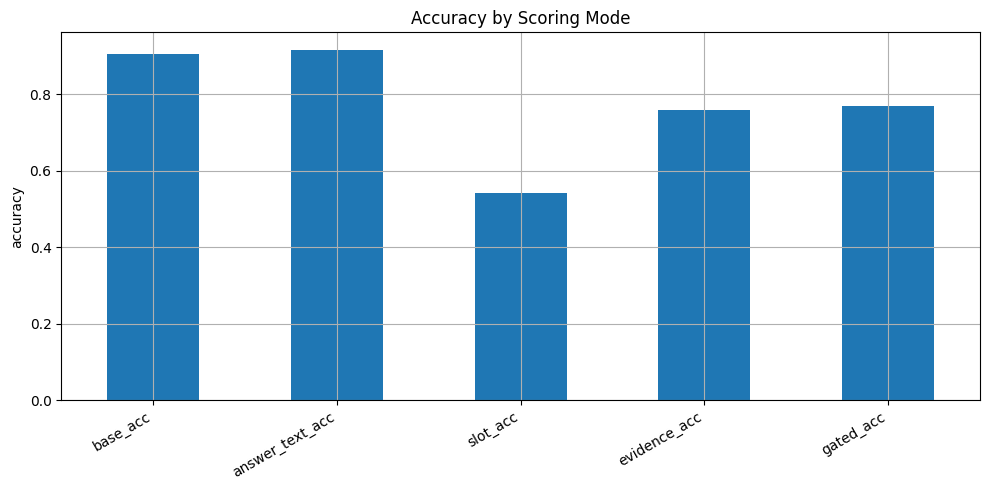

<Figure size 1400x500 with 0 Axes>

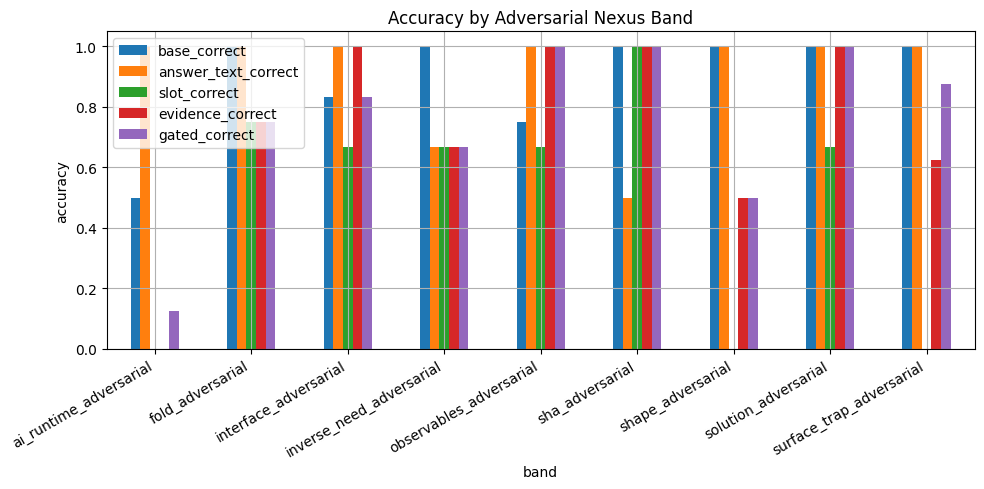

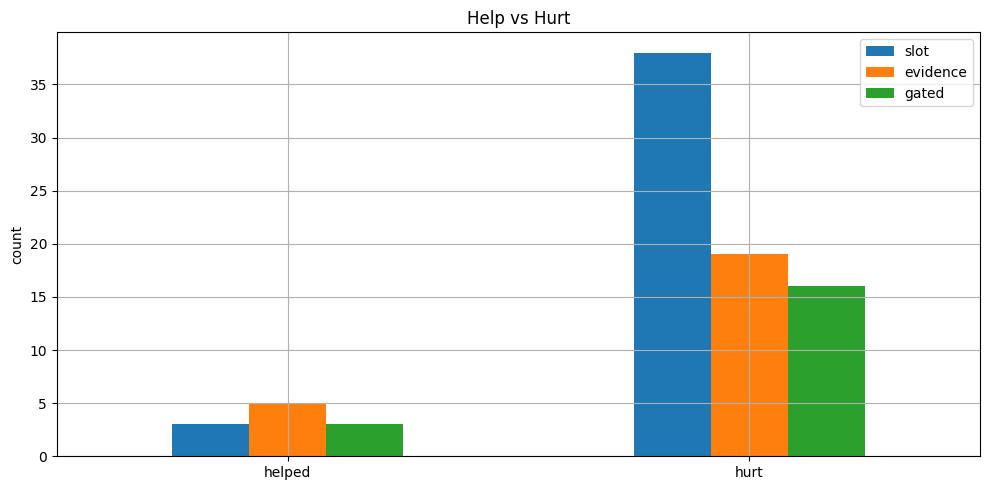

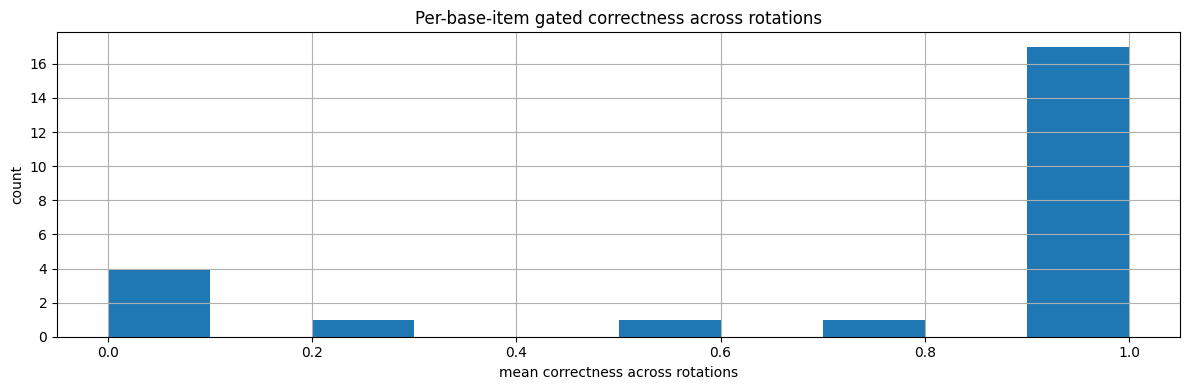

In [13]:
plt.figure(figsize=(11,4))
summary[["base_acc","answer_text_acc","slot_acc","evidence_acc","gated_acc"]].T.plot(kind="bar",legend=False)
plt.title("Accuracy by Scoring Mode")
plt.ylabel("accuracy")
plt.xticks(rotation=30,ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14,5))
by_band.set_index("band")[["base_correct","answer_text_correct","slot_correct","evidence_correct","gated_correct"]].plot(kind="bar")
plt.title("Accuracy by Adversarial Nexus Band")
plt.ylabel("accuracy")
plt.xticks(rotation=30,ha="right")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "slot":[results_df.slot_helped.sum(),results_df.slot_hurt.sum()],
    "evidence":[results_df.evidence_helped.sum(),results_df.evidence_hurt.sum()],
    "gated":[results_df.gated_helped.sum(),results_df.gated_hurt.sum()],
},index=["helped","hurt"]).plot(kind="bar")
plt.title("Help vs Hurt")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
by_base_item["gated_correct"].hist(bins=10)
plt.title("Per-base-item gated correctness across rotations")
plt.xlabel("mean correctness across rotations")
plt.ylabel("count")
plt.tight_layout()
plt.show()


In [14]:
for row_id in interesting["id"].head(24):
    print("="*100)
    print("CASE:", row_id)
    display(results_df[results_df.id==row_id][[
        "id","base_id","band","gold_choice","base_choice","base_correct","base_margin",
        "answer_text_choice","answer_text_correct","answer_text_margin",
        "slot_choice","slot_correct","slot_margin","slot_delta_vs_base",
        "evidence_choice","evidence_correct","evidence_margin","evidence_delta_vs_base",
        "gated_choice","gated_correct","gate_reason"
    ]])
    print("NEED SLOT:")
    print(results_df[results_df.id==row_id]["need_slot_text"].iloc[0])
    display(evidence_tables[row_id].sort_values("energy"))


CASE: adv_car_01__rot0


,id,base_id,band,gold_choice,base_choice,base_correct,base_margin,answer_text_choice,answer_text_correct,answer_text_margin,...,slot_correct,slot_margin,slot_delta_vs_base,evidence_choice,evidence_correct,evidence_margin,evidence_delta_vs_base,gated_choice,gated_correct,gate_reason
8,adv_car_01__rot0,adv_car_01,interface_adversarial,"a readable driver surface: wheel, pedals, seat...",a semantic category called vehicle,0,5.125,"a readable driver surface: wheel, pedals, seat...",1,3.380859,...,1,0.062625,0.062625,"a readable driver surface: wheel, pedals, seat...",1,0.854482,0.062625,a semantic category called vehicle,0,protect_locked_base_slot_not_positive


NEED SLOT:
required_operation: interface-collapse
preserved_function: car components
boundary_conditions: combustion engine; gearbox; sensors; tire friction; steering geometry; safety features
anti_fits: incorrect interface-collapse; missing component
admissible_shape: interface
failure_modes: incomplete interface; missing component
source: llm


,choice_idx,choice,letter_score,answer_text_score,slot_llm_score,slot_embed_score,slot_embed_pos,slot_embed_neg,slot_score,letter_z,...,slot_z,pair_fit,contradiction_z,energy,slot_dim_required_operation,slot_dim_preserved_function,slot_dim_boundary_conditions,slot_dim_anti_fits,slot_dim_admissible_shape,slot_dim_failure_modes
1,1,"a readable driver surface: wheel, pedals, seat...",-23.828125,-2.486328,-4.057292,0.294442,0.443995,0.149554,0.799675,0.251293,...,0.994499,0.661501,-1.015315,-1.507107,-3.984375,-4.804688,-2.976562,-4.101562,-3.343750,-5.132812
0,0,a semantic category called vehicle,-18.703125,-6.722656,-3.171875,0.170566,0.239707,0.069140,0.737050,1.529186,...,0.916616,0.665285,-0.317205,-0.652625,-2.039062,-3.789062,-1.906250,-3.710938,-3.078125,-4.507812
2,2,a detailed list of engine nouns,-28.078125,-5.867188,-4.779948,0.171723,0.258278,0.086555,-0.434586,-0.808423,...,-0.540463,0.638194,-0.328907,0.433157,-4.312500,-5.656250,-3.882812,-4.351562,-5.289062,-5.187500
3,3,a symbol of transportation culture,-28.734375,-6.167969,-4.533854,0.024082,0.080297,0.056214,-1.102140,-0.972056,...,-1.370652,0.557798,1.661426,1.726575,-4.500000,-5.046875,-3.742188,-4.195312,-4.914062,-4.804688


CASE: adv_car_01__rot2


...

,choice_idx,choice,letter_score,answer_text_score,slot_llm_score,slot_embed_score,slot_embed_pos,slot_embed_neg,slot_score,letter_z,...,slot_z,pair_fit,contradiction_z,energy,slot_dim_required_operation,slot_dim_preserved_function,slot_dim_boundary_conditions,slot_dim_anti_fits,slot_dim_admissible_shape,slot_dim_failure_modes
1,1,complete proof by label,-21.531250,-5.773438,-4.807292,-0.088520,0.118373,0.206893,0.421316,0.053546,...,1.119604,0.602803,-0.708589,-0.946573,-1.531250,-4.812500,-6.390625,-5.476562,-3.750000,-6.882812
0,0,surface citation without operational collapse,-18.406250,-4.257812,-7.680990,0.015456,0.185347,0.169891,0.083432,1.530670,...,0.221712,0.742274,-0.774216,-0.896054,-7.632812,-7.578125,-7.945312,-7.242188,-7.476562,-8.210938
2,2,a physical repair,-22.375000,-14.000000,-5.782552,-0.076703,0.042465,0.119168,0.104401,-0.345278,...,0.277436,0.629192,-0.207054,0.350986,-4.593750,-5.789062,-6.773438,-5.460938,-5.375000,-6.703125
3,3,a valid observable because it sounds formal,-24.265625,-5.203125,-5.686198,-0.164308,-0.010962,0.153346,-0.609150,-1.238938,...,-1.618752,0.617564,1.689858,1.491642,-2.960938,-6.382812,-7.125000,-6.320312,-4.492188,-6.835938


CASE: adv_surface_02__rot1


,id,base_id,band,gold_choice,base_choice,base_correct,base_margin,answer_text_choice,answer_text_correct,answer_text_margin,...,slot_correct,slot_margin,slot_delta_vs_base,evidence_choice,evidence_correct,evidence_margin,evidence_delta_vs_base,gated_choice,gated_correct,gate_reason
57,adv_surface_02__rot1,adv_surface_02,surface_trap_adversarial,surface citation without operational collapse,surface citation without operational collapse,1,7.53125,surface citation without operational collapse,1,0.394531,...,0,0.316915,0.337884,complete proof by label,0,0.043539,0.337884,surface citation without operational collapse,1,keep_base_default


NEED SLOT:
required_operation: fold path
preserved_function: impressive theorem name
boundary_conditions: never shows the fold path; never shows the boundary; never shows the preserved function
anti_fits: incorrect theorem name; non-impressive theorem name
admissible_shape: theorem name
failure_modes: theorem name does not impress; the theorem name is generic
source: llm


,choice_idx,choice,letter_score,answer_text_score,slot_llm_score,slot_embed_score,slot_embed_pos,slot_embed_neg,slot_score,letter_z,...,slot_z,pair_fit,contradiction_z,energy,slot_dim_required_operation,slot_dim_preserved_function,slot_dim_boundary_conditions,slot_dim_anti_fits,slot_dim_admissible_shape,slot_dim_failure_modes
0,0,complete proof by label,-26.234375,-6.679688,-4.807292,-0.088520,0.118373,0.206893,0.421316,-0.456463,...,1.119604,0.605395,-0.708905,-0.930047,-1.531250,-4.812500,-6.390625,-5.476562,-3.750000,-6.882812
3,3,surface citation without operational collapse,-18.312500,-5.675781,-7.680990,0.015456,0.185347,0.169891,0.083432,1.696345,...,0.221712,0.760630,-0.788619,-0.886508,-7.632812,-7.578125,-7.945312,-7.242188,-7.476562,-8.210938
1,1,a physical repair,-25.843750,-16.781250,-5.782552,-0.076703,0.042465,0.119168,0.104401,-0.350309,...,0.277436,0.619586,-0.187786,0.370942,-4.593750,-5.789062,-6.773438,-5.460938,-5.375000,-6.703125
2,2,a valid observable because it sounds formal,-27.828125,-6.070312,-5.686198,-0.164308,-0.010962,0.153346,-0.609150,-0.889573,...,-1.618752,0.609652,1.685310,1.445613,-2.960938,-6.382812,-7.125000,-6.320312,-4.492188,-6.835938


## Readout

v54 locks if:

$$
\text{gated\_acc} > 0.979167
$$

or if it keeps:

$$
\text{gated\_hurt}=0
$$

while repairing the two remaining `adv_car_01` failures.

Strongest lock:

$$
\text{slot\_acc} \uparrow
\quad\land\quad
\text{slot\_hurt} \downarrow
$$

because that means the outward slot itself is now real, not just the gate.

If the compiler slot works better than the LLM-generated slot, the next practical move is:

$$
\boxed{
\text{train/tune a slot-builder on compiler-quality slot schemas}
}
$$

That is the AI work:
the prompt emits the missing-shape contract first, then candidate binding is just collapse.
